# Getting started with CoPhaser

CoPhaser infers a **phase** for every cell from raw counts - the cell cycle here, but the same
model handles the circadian clock, the somite clock or any other cycle. It works across
sequencing technologies and is cheap to train: a few minutes on a GPU for 50,000 cells, about
an hour for two million.

This notebook is the one to start with. It takes an `.h5ad` file to validated phases, with
**every hyperparameter derived from the data**. The only thing you tell CoPhaser is whether
your sample is a cell line or a tissue.

> **Prefer not to write code?** The same workflow is available as a five-step graphical
> interface - see `2_gui_tutorial.ipynb`. It runs the identical code path, so the results are
> the same.

### Why the automatic route is the default

Training outcome is *bimodal* in the random seed. On most datasets a seed either finds the
cycle and recovers the expected phases almost exactly, or settles somewhere clearly worse, with
little in between. So the recipe is to train a few times and *detect* which runs are good,
using the same biological checks you would otherwise make by eye.

Two things this does **not** do:

- It is **not more accurate than careful hand tuning**. On the nine cell-cycle datasets behind
  the paper it reaches the same quality as per-dataset hyperparameters chosen by hand, but is less stable than the carefully hand tuned parameters.
- It **cannot rescue data that does not carry the signal**. Sequencing depth sets a ceiling no
  hyperparameter moves. Step 1 tells you where you stand before you spend any computing time.

### Where to go next

| notebook | what it covers |
|---|---|
| `2_gui_tutorial.ipynb` | the same workflow without writing code |
| `3_hyperparameter_tuning.ipynb` | what each hyperparameter does, and what a bad one looks like |
| `4_cancer_tutorial.ipynb` | a sample where most cells are **not** cycling |

The `paper/` folder reproduces every figure in the manuscript.

Running this notebook (~13,000 cells) takes ~2 minutes on a GPU, ~4 on a CPU, ~10 on a laptop.


## Package and Environment Set-Up
0) Download this repo
1) Create a [conda environment](https://www.anaconda.com/docs/getting-started/miniconda/main)
```bash
conda create -n "CoPhaser_Env" python=3.13
conda activate CoPhaser_Env
```
2) Install PyTorch with CUDA support (if you want to use the GPU)
   **Note:** Check your CUDA driver version (`nvidia-smi`) and install the compatible PyTorch version. 
   Go to [the official page](https://pytorch.org/) for more information. The code was tested using the version 2.9.1.
   
   To download CUDA 12.6, for instance, with the latest PyTorch version:
```bash
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126
```
3) Install the package
```bash
cd CoPhaser/
pip install .
```

You should now be able to use an environment called ``CoPhaser_env`` containing all the required packages.

## Data Processing

CoPhaser works directly with the raw counts, and it does not require the separation of the spliced and unspliced counts. A basic filtering, with the removal of data of low quality should be performed prior to the model training. As an example, I will use a dataset of RPE1 cells containing 2 batches. I advise the interested reader to first generate the dataset using the notebook ``0_generate_rp1_dataset.iypnb``, since creating the dataset should not take too long. (Most of the running time depends on your internet connection speed, to download the 300 mb dataset).

In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

from cophaser import utils, gene_sets, plotting
from cophaser import CoPhaser, Trainer, Loss
from cophaser import (
    preflight,  # is this dataset worth training on at all?
    suggest_n_latent,  # the one choice you make: cell line or tissue
    auto_hyperparameters,  # everything else, derived from the counts
    fit_with_restarts,  # train N times, ranked best first, no ground truth
    quality_metrics,  # the unsupervised checks, as numbers
)

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
DATA_FOLDER = "data"
adata = sc.read_h5ad(os.path.join(DATA_FOLDER, "rpe1_velocycle.h5ad"))
adata

AnnData object with n_obs × n_vars = 14259 × 36591
    obs: 'batch', 'n_counts', 'n_genes'
    obsm: 'X_pca', 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

In [4]:
# quality control: filter out cells with less than 200 genes and genes expressed in less than 3 cells.
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

Your adata should contain a layer with the raw counts. If it is in the adata.X, you can run `adata.layers["total"]=adata.X.copy()` to create a layer named `total` containing the data.

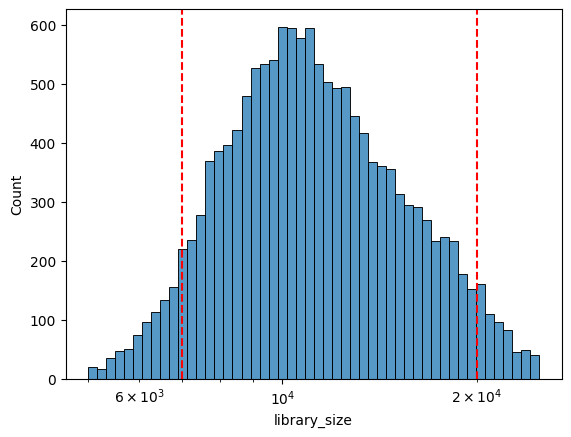

In [5]:
# filter outliers based on the library size (total counts per cell)
adata.obs["library_size"] = adata.layers["spliced"].sum(axis=1).A1
sns.histplot(adata.obs["library_size"], bins=50, log_scale=True)
min_counts = 7000
max_counts = 20000
plt.axvline(min_counts, color="red", linestyle="--")
plt.axvline(max_counts, color="red", linestyle="--")

In [6]:
layer = "spliced"
adata = adata[
    (adata.obs["library_size"] >= min_counts)
    & (adata.obs["library_size"] <= max_counts)
].copy()
adata

AnnData object with n_obs × n_vars = 12843 × 19349
    obs: 'batch', 'n_counts', 'n_genes', 'library_size'
    var: 'n_cells'
    obsm: 'X_pca', 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

We will first define the rhythmic gene sets - genes known to display rhythmic patterns with respect to the cell cycle.

We will then define the context genes - genes providing enough information to assign cells to different biological contexts. Here and most of the time we just use the 2000 most variable genes.

In [7]:
# the cycling gene set, and the context genes the model will reconstruct
rhythmic_genes = [
    g.upper()
    for g in gene_sets.SMALL_CELL_CYCLE_GENE_SET
    if g.upper() in adata.var_names
]
context_genes = utils.get_variable_genes(adata)
print(f"{len(rhythmic_genes)} cycling genes, {len(context_genes)} context genes")

98 cycling genes, 2000 context genes


## Step 1 - Before training: can this dataset be used with the automatic tuning?

`preflight` reads three limits off the object.

| what it checks | why | what was measured |
|---|---|---|
| **median library size** | the dominant limit | thinning the validation datasets, best-of-N agreement averages 0.49 below 600 UMI, 0.69 at 600-1,500, 0.81 at 1,500-3,000 and 0.93 above 3,000. Below ~1,000 UMI the phase is unreliable at every setting tried |
| **rhythmic genes present** | the model needs enough of them | removing a quarter of the annotated set costs ~0.03, half costs ~0.08, three quarters is not usable. ~50 is a working minimum |
| **marker genes selected** | the *quality score* needs them | the histones that peak in S phase are what tells a good run from a bad one. With none of them, restart selection falls back to weaker signals |

In [8]:
report = preflight(
    adata,
    layer=layer,
    rhythmic_gene_names=rhythmic_genes,
    context_genes=context_genes,
)
print(f"{report['n_cells']} cells, median library size {report['median_umi']:.0f} UMI")
print(f"{report['n_rhythmic_genes']} rhythmic genes present")
print(
    f"{report['marker_genes']['n_selected']} marker (histone) genes among the context genes, "
    f"{report['marker_genes']['n_in_data']} present in the object"
)
print("warnings:", report["warnings"] or "none")

12843 cells, median library size 11039 UMI
98 rhythmic genes present
6 marker (histone) genes among the context genes, 44 present in the object
warnings: none


On this dataset: ~12,800 cells at ~11,000 median UMI, 98 rhythmic genes and 6 histone
genes selected. Comfortably above every threshold, so no warnings - expect a good result.

## Step 2 - The one input you supply

`n_latent` is the size of the non-periodic latent space, and it is a property of your sample
that you already know rather than something to fit:

- **cell line** -> 2. There is little structured variation besides the cycle, and a wide latent
  space invites it to absorb the cycle itself.
- **tissue** -> 10. Cell types, donors and batches need somewhere to go that is not the phase.

This matches the choice made for every dataset in the paper.

In [9]:
n_latent = suggest_n_latent("cell_line")  # RPE1 cells; use "tissue" for biopsies
n_latent

2

## Step 3 - Everything else, derived from the counts

`auto_hyperparameters` reads the loaded model and returns arguments ready for `Trainer`. Pass
`adata` as well, so the cell-cycle scoring uses the true library size and the full gene set
rather than only the selected genes.

Three rules are doing the work.

**Is a large fraction of cells not cycling?** Cells are scored G1/S/G2M with the standard
Tirosh/Seurat marker scoring. Above 45% G1 the Bernoulli branch is switched on
(`cycling_status_prior = 0.1`), which lets the model set cells aside instead of forcing a phase
on them. This reproduced the choice made by hand for all nine datasets in the paper. Note that
near the threshold the decision is close to free - on a dataset sitting right at it, priors of
0.1, 0.3 and 1.0 gave similar results, so you do not have to agonise over a borderline case.

**How heavy should the reconstruction be?** The ELBO target is
`3200 / (fraction of cells carrying the cycle)`. The reconstruction term is averaged over
*every* cell, while the entropy, mutual-information and closed-circle terms it competes with
are averaged over the *cycling* cells only - so when only a minority carry cycle signal the
reconstruction has to be weighted up for that signal to compete.

That correction applies exactly when the Bernoulli branch is on. With the branch off every
cell *is* a cycling cell, the regularisers already see all of them, and the fraction is 1: the
target is a flat 3,200. The same rule covers the circadian clock, where no cell rests.

**What weights reach that target?** Before training, the ELBO at unit weights is predicted by
the cost of a trivial "every gene at its mean rate" negative binomial model - no training
needed, and accurate to about 15%. The weights are then set so the first epoch already lands
near the target.

**And if the branch comes on, the cycle gets a head start.** With a mostly non-cycling sample
the cycling-status encoder has to decide which cells carry a phase while the model is still
discovering what a phase looks like, and it can settle that wrongly and never revisit it. So
when the branch is on - and only then - the rhythmic decoder starts from the packaged RPE
Fourier coefficients and stays frozen for 20 epochs, which is the
`unfreeze_epoch_layer=[(20, "rhythmic_decoder")]` you will see in the hyperparameters below.


In [10]:
# Define the model's arguments once and reuse them, so the model the rules are derived from
# and the models the restarts train cannot drift apart.
model_params = dict(
    rhythmic_gene_names=rhythmic_genes,
    context_genes=context_genes,
    n_latent=n_latent,
)

probe = CoPhaser(**model_params)
probe.load_anndata(adata, layer_to_use=layer)

params = auto_hyperparameters(probe, cycle="cell_cycle", adata=adata, layer=layer)
params["trainer"]

auto hyperparameters: likelihood weights 3.45 (rhythmic) / 3.45 (non-rhythmic) to target an ELBO of 3200; cycling_status_prior 1.0 - 16% of cells scored G1, below the 45% threshold


{'rhythmic_likelihood_weight': 3.4513262303201886,
 'non_rhythmic_likelihood_weight': 3.4513262303201886,
 'cycling_status_prior': 1.0,
 'closed_circle_weight': 10.0}

In [11]:
# what the rules read off the data to get there
d = params["diagnostics"]
print(
    f"G1 / S / G2M fractions : {d['g1_fraction']:.2f} / {d['s_fraction']:.2f} / {d['g2m_fraction']:.2f}"
)
print(
    f"-> cycling_status_prior: {params['trainer']['cycling_status_prior']}  ({d['reason']})"
)
print(f"predicted ELBO at unit weights: {d['predicted_elbo_at_unit_weights']:.0f}")
print(
    f"-> ELBO target {d['elbo_target']:.0f}, so likelihood weight "
    f"{params['trainer']['rhythmic_likelihood_weight']:.2f}"
)

G1 / S / G2M fractions : 0.16 / 0.18 / 0.65
-> cycling_status_prior: 1.0  (16% of cells scored G1, below the 45% threshold)
predicted ELBO at unit weights: 927
-> ELBO target 3200, so likelihood weight 3.45


On RPE1: 16% of cells scored G1, well below the 45% threshold, so the Bernoulli branch
stays off, the fraction is 1, the target is 3,200, and no warm start is applied. A cancer or
adult-tissue sample typically lands at 55-65% G1, which switches the branch on, raises the
target to 7,000-9,000 and turns on the Fourier warm start - see `4_cancer_tutorial.ipynb`.


## Step 4 - Train several times and keep the best

This is the part that actually buys reliability. `fit_with_restarts` trains `n_restarts` times
from different initialisations and ranks them by the unsupervised checks - no ground truth
involved. It returns the runs **sorted best first**, so `restarts[0]` is the one selection
chose and `restarts[1]` is the runner-up you can compare it against.

You give it the model arguments and the hyperparameters, not a function that builds the model:
every restart is then constructed identically, which removes the easiest way to get this wrong
(a model quietly loaded from a different object, or a warm start applied to the first restart
only).

Three restarts capture most of the benefit; but five might help in some rare occasions. The cost is
linear in the number of restarts, and progress is reported over *every epoch of every restart*.

Pass `adata=` so the marker checks can use every histone gene in the object rather than only
those that survived gene selection - it costs nothing at training time and helps most on the
datasets where gene selection kept the fewest.

In [12]:
restarts = fit_with_restarts(
    adata=adata,
    layer=layer,
    model_params=model_params,
    trainer_params=params["trainer"],  # everything auto_hyperparameters decided
    cycle="cell_cycle",
)

# restarts comes back ranked, best first
best = restarts[0]
model, trainer = best["model"], best["trainer"]

Training:   0%|          | 0/600 [00:00<?, ?epoch/s]

Training: 100%|██████████| 600/600 [03:31<00:00,  2.84epoch/s]

Best restart: seed 1 (score 1.00)


In [13]:
restarts[0]

{'marker_ratio': 18.06083802652443,
 'marker_resultant': 0.7014898657798767,
 'phase_separation': -0.016173672680037887,
 'profile_reproducibility': 0.1323718841586785,
 'cycling_fraction': nan,
 'library_size_ratio': 1.455137785444265,
 'rhythmic_amplitude': 0.45563387870788574,
 'marker_pair_spread': -0.22441095113754272,
 'n_marker_genes': 12,
 'n_marker_genes_available': 44,
 'expected_phase_separation': 1.9801182325047315,
 'phase_uniformity': 0.9903674742225758,
 'cycling_status_prior': 1.0,
 'seed': 1,
 'minutes': 1.1609073678652446,
 'model': CoPhaser(
   (rhythmic_encoder): RhythmicEncoderVAE(
     (fc1): Linear(in_features=98, out_features=64, bias=False)
     (fc2): Linear(in_features=64, out_features=32, bias=False)
     (fc_mu): Linear(in_features=32, out_features=2, bias=False)
     (kappa_net): NeuralNet(
       (neural_net): Sequential(
         (0): Linear(in_features=98, out_features=128, bias=True)
         (1): GELU(approximate='none')
         (2): Linear(in_featur

## Step 5 - Reading the quality report

Each restart comes back with its signals:

**Ranking signals** - comparable only *between runs of the same dataset*, never against an
absolute number. Their scale depends on how many marker genes survived gene selection, so a
score of 30 on one dataset and 5 on another says nothing about which is better.

| signal | what it measures |
|---|---|
| `marker_ratio`, `marker_resultant` | how sharply the histone genes peak in one phase window |
| `phase_separation` | how far apart the S markers (PCNA, MCM6) and the G2/M markers (TOP2A, MKI67) peak. Reported as a *negated deviation* from a quarter cycle, so 0 is perfect and more negative is worse - like every other signal here, larger is better |
| `profile_reproducibility` | whether rhythmic gene profiles reproduce on an independent half of the cells, above the same quantity for all other genes |
| `cycling_fraction` | how many cells the Bernoulli branch keeps (only when it is on) |

**Vetoes** - these *do* have thresholds that mean the same thing on any dataset, and a run
tripping one is demoted below every other candidate:

| veto | fires when | what it means |
|---|---|---|
| `phase_uniformity` < 0.88 | the phase has stopped being evenly spread | the reconstruction has overpowered the entropy loss: the ELBO target is too high |
| `library_size_ratio` > 3 | library size swings more than 3x around the cycle | the phase is tracking sequencing depth rather than the cycle |
| `cycling_fraction` < 1.5 x prior | the Bernoulli branch never escaped its prior | with the branch on, 97% of the runs this flags are bad |

In [14]:
import pandas as pd

cols = [
    "seed",
    "minutes",
    "score",
    "marker_ratio",
    "marker_resultant",
    "phase_separation",
    "profile_reproducibility",
    "phase_uniformity",
    "library_size_ratio",
]
# already ordered best first
pd.DataFrame(restarts)[cols].round(3)

,seed,minutes,score,marker_ratio,marker_resultant,phase_separation,profile_reproducibility,phase_uniformity,library_size_ratio
0,1,1.161,1.000,18.061,0.701,-0.016,0.132,0.990,1.455
1,2,1.168,0.375,15.550,0.385,-0.549,0.026,0.955,1.353
2,0,1.193,0.125,5.278,0.360,-0.524,0.024,0.977,1.141


`score` is the combined rank and the list comes back ordered by it, so `restarts[0]` is the
run selection chose. A restart that tripped a veto has a score below 0, which is how you spot
it.

Compare the rows above: the three restarts are not equivalent. Seed 1 scores 1.0 with a sharp
marker peak (`marker_ratio` 18.1) and a phase separation essentially on a quarter cycle
(-0.016). Seed 0 scores 0.125 with a marker ratio of 5.3, a separation 0.52 rad off, and a
fifth of seed 1's `profile_reproducibility`. That is the bimodality described at the top of
this notebook, on this very dataset: had you run once with seed 0, you would have kept the
clearly worse fit without knowing.

If the spread of `score` across restarts is wide, your dataset is one of the seed-sensitive
ones and the restarts earned their keep. If every restart scores similarly *and* passes the
biological checks below, one run would have been enough - but you only know that afterwards.


## Step 6 - Confirm it biologically

The quality score is a proxy. The checks that matter are biological, and you should still look
at them: marker genes peaking in the right order around the cycle, the library size roughly
doubling before division, and the histone genes peaking in S phase.


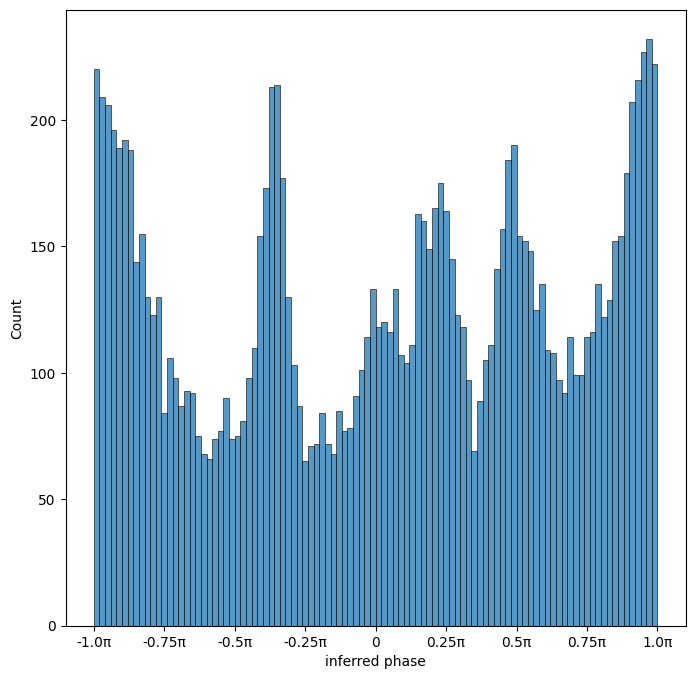

In [15]:
model.to("cpu")
generative_outputs, space_outputs = model.get_outputs()
thetas = space_outputs["theta"]
plotting.modify_axis_labels()
sns.histplot(thetas, bins=100)
plt.xlabel("inferred phase")
plt.show()

44 histone genes found in data
Getting posterior and calculating entropy...


100%|██████████| 1/1 [00:00<00:00,  3.07it/s]


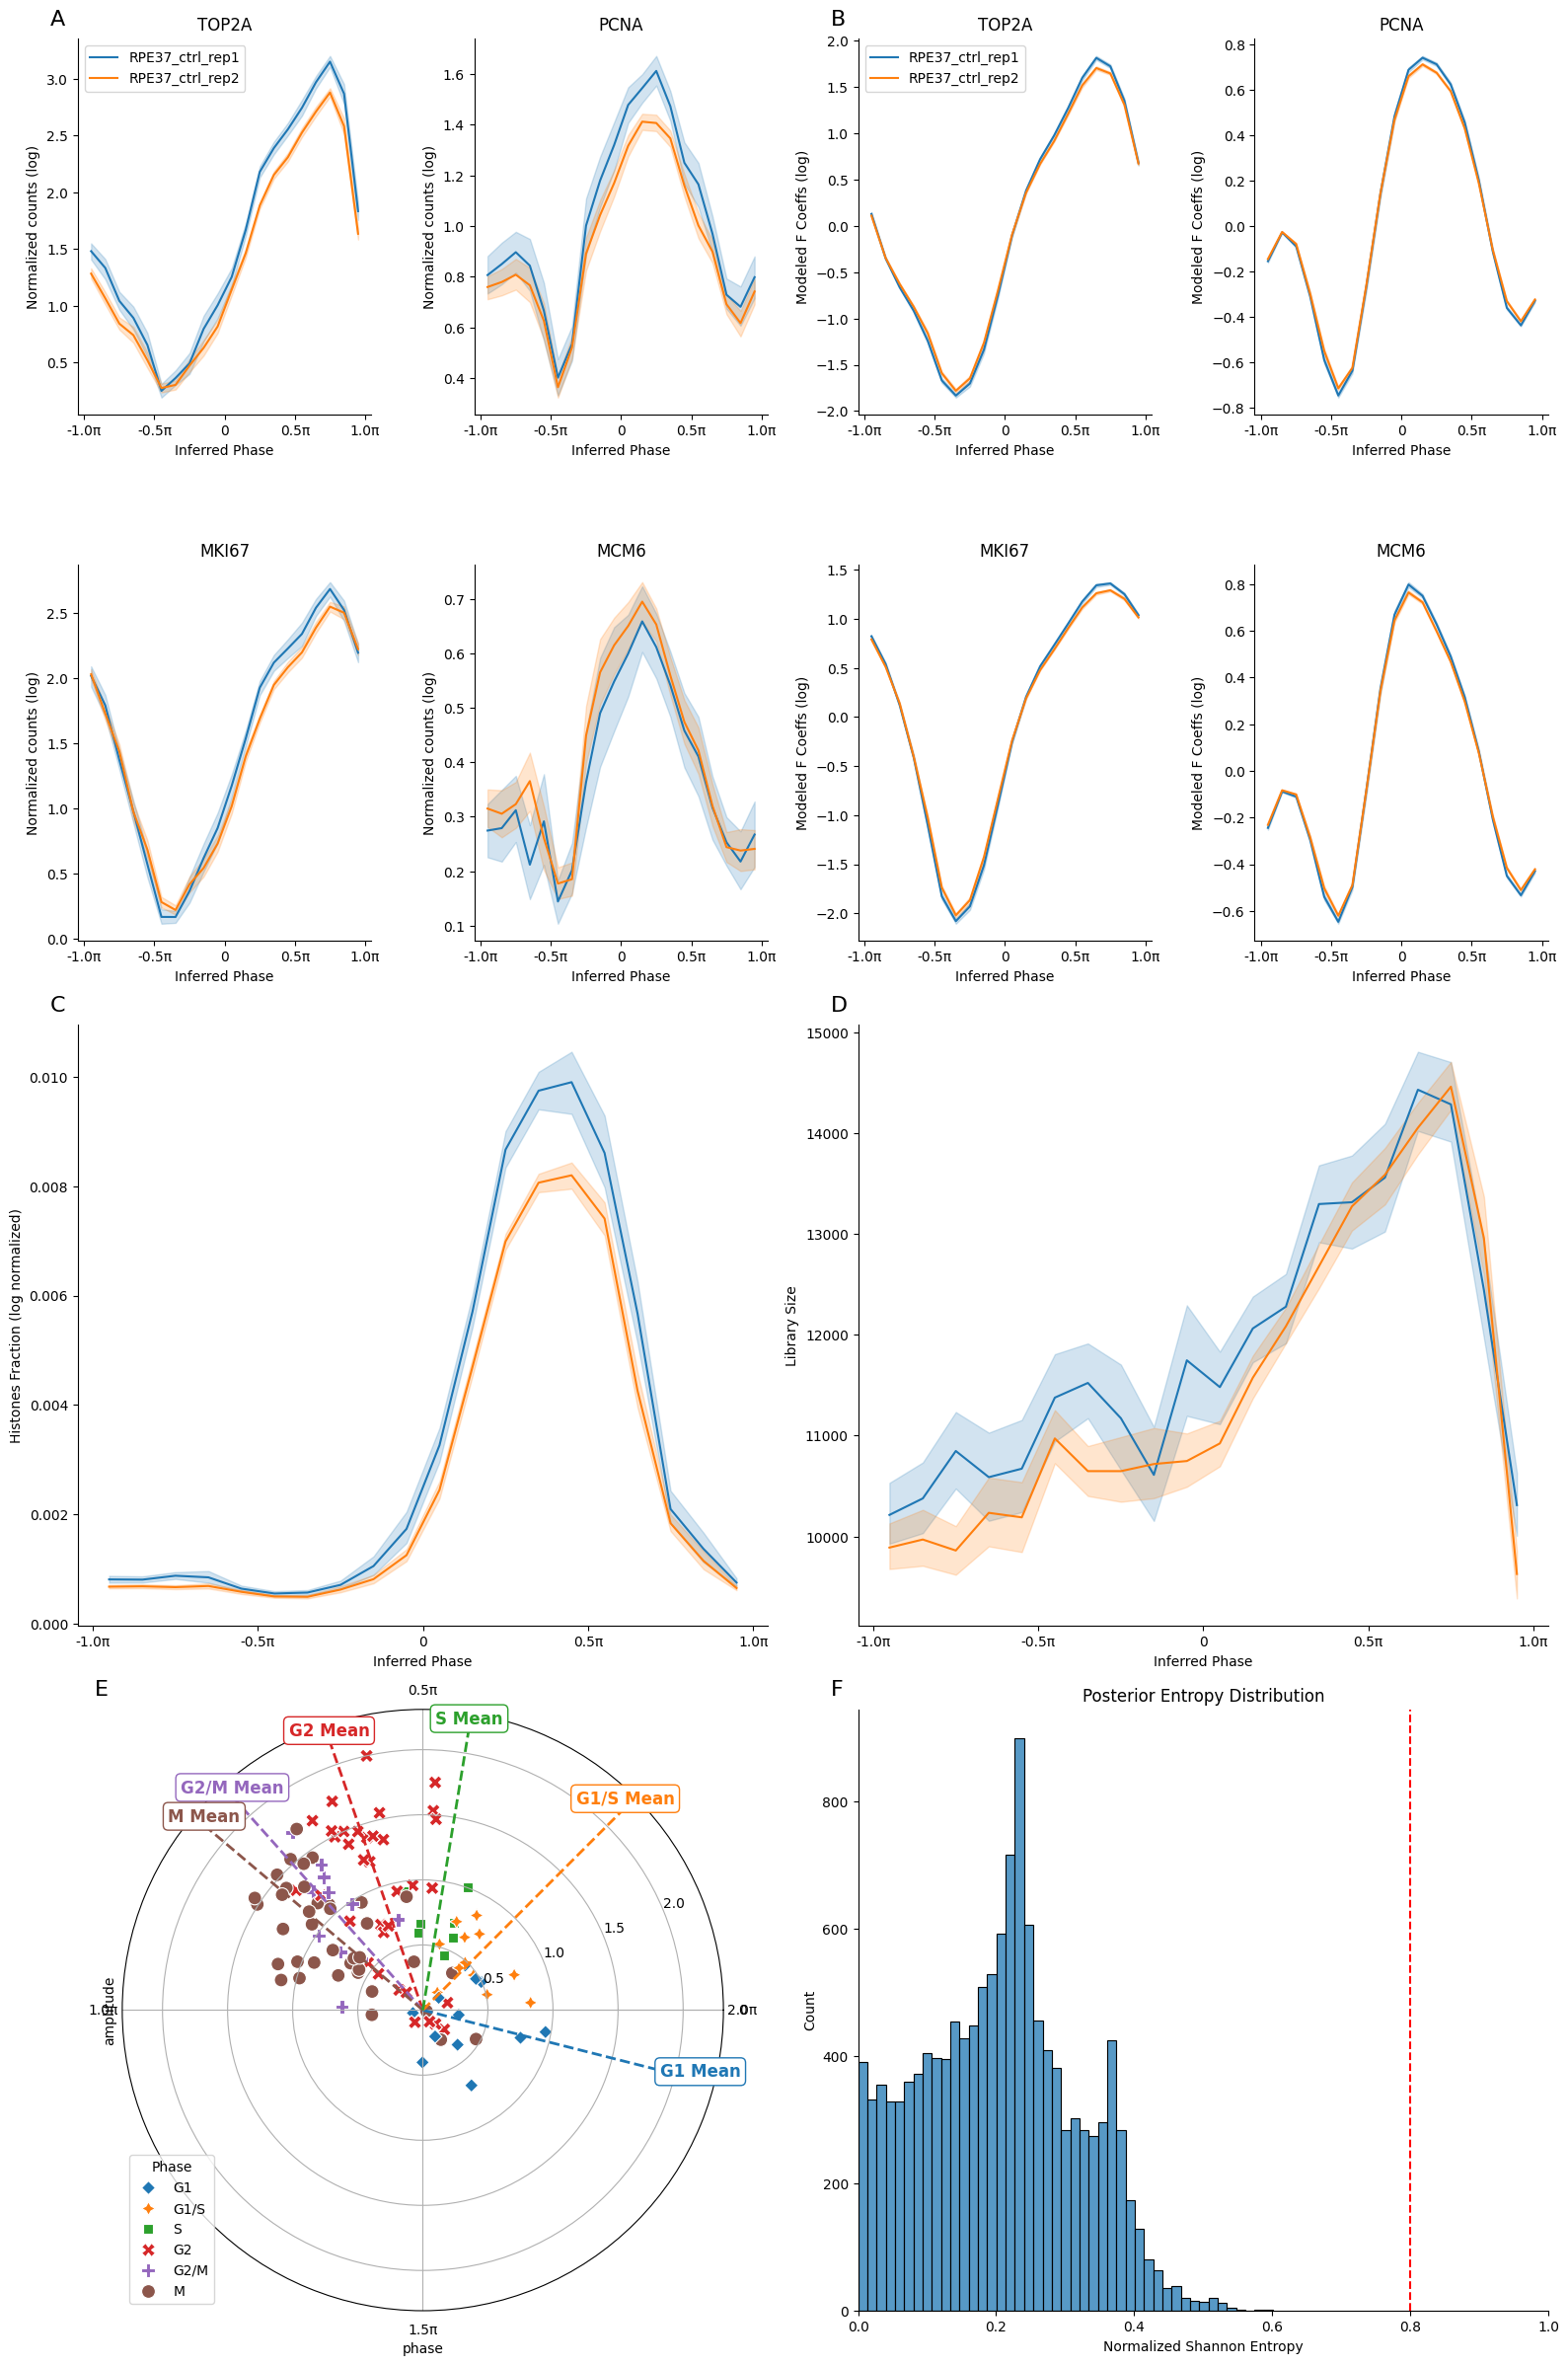

Validation of the inferred cell cycle phases.

A. Reconstructed gene expression profiles, obtained by binning cells according to inferred phase and averaging 
log(1 + counts per 10,000) for the indicated gene.
(You should see: Top2a 2-3 log, peak G2M; Mki67 2-3 log, peak G2M; Pcna 1-2 log, peak S; Mcm6 1-2 log, peak S.
If Top2a/Mki67 are not in phase and phase shifted with respect to Pcna/Mcm6, the inferred phases are wrong.)

B. Fourier derived predicted gene expression profiles in log
(You should see: Top2a 2-3 log, peak G2M; Mki67 2-3 log, peak G2M; Pcna 1-2 log, peak S; Mcm6 1-2 log, peak S.)

C. Histone fraction in function of inferred phase.
(You should see a peak during the S phase (see D and E to determine the S phase).)

D. Library size in function of inferred phase.
(You should ~see a doubling of the library size.)

E. Scatter plot of the inferred peaking phases and amplitudes of annotated cell cycle genes.
(You should ~see a progression from G1-G1/S-S-G2-M.)

F. Distribution

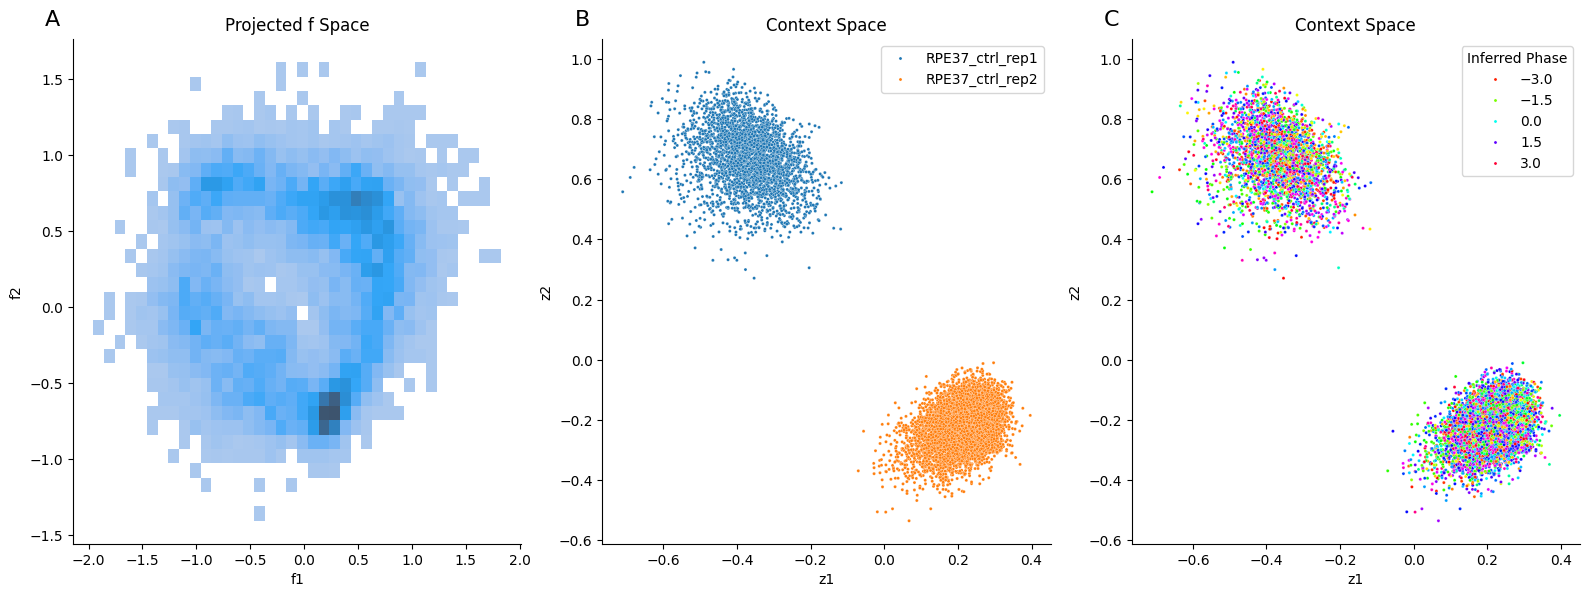

Latent space visualization of the inferred cell cycle phases.
    
A. Histogram of the projected f space, which defines the inferred phase. 
(Seeing an annulus is a good signal, but this depends on the weight of Trainer's closed_circle_weight)

B. Context space colored by the provided hue (if any).

C. Context space colored by the inferred phase. 
(You should see a ~ random distribution of the inferred phases in the context space, since the mutual
information between the context and the inferred phase is minimized.)



In [16]:
plotting.plot_cell_cycle_validations(
    model, space_outputs, generative_outputs, adata, layer, hue_key="batch"
)

You should always ensure that the cycle captured correspond to your biological cycle. Here we present some quality check, such as gene profiles, peaking phase ordering, #UMI per cell and histones peak for the cell cycle. Your plot should be similar to these. If they are not this mean that the training of the model did not converged towards the expected biological cycle, and retraining the model with another seed is required.

In [17]:
# the same checks as numbers, for the kept model
m = quality_metrics(model, cycle="cell_cycle", adata=adata, layer=layer)
{
    k: (round(v, 3) if isinstance(v, float) else v)
    for k, v in m.items()
    if k
    in (
        "marker_ratio",
        "phase_separation",
        "expected_phase_separation",
        "library_size_ratio",
        "phase_uniformity",
        "rhythmic_amplitude",
    )
}

{'marker_ratio': 18.061,
 'phase_separation': -0.016,
 'library_size_ratio': 1.455,
 'rhythmic_amplitude': 0.456,
 'expected_phase_separation': 1.98,
 'phase_uniformity': 0.99}

`expected_phase_separation` is worth a glance next to `phase_separation`: the gap between
the S and G2/M marker peaks is not a fixed quarter-cycle, it is set by how much of the cycle
each phase occupies in *your* population.

## When it does not work

If the biological checks fail, the diagnostics point at a specific knob rather than a search.
The direction below is what the sweeps behind these rules actually measured.

| what you see | most likely cause | what to change |
|---|---|---|
| `phase_uniformity` below 0.88; phases bunched up | reconstruction is overpowering the entropy loss | halve the ELBO target: `auto_hyperparameters(..., elbo_target=...)` |
| `library_size_ratio` above 3 | the phase is following sequencing depth | usually the same cause; try a lower target first |
| branch on, `cycling_fraction` stuck near the prior | reconstruction too *light* for the cycling cells to compete | raise the ELBO target. Raising `cycling_status_prior` to 0.3 also helps, but it is a symptom-level fix - at the right target 0.1 is better |
| every restart looks equally mediocre, low depth | the depth ceiling from Step 1 | nothing to tune; more cells will not help either, more reads would |
| scores disagree with what you see by eye | too few marker genes for the score to be reliable | check `marker_gene_coverage`; trust your eyes, and add restarts |

A worked set of failure examples, with figures, is in `3_hyperparameter_tuning.ipynb`.

## What is deliberately left to you

Two knobs have a large effect but no rule, because the sweeps found their best value pointing
in *opposite* directions on different datasets with no predictor:

- the **rhythmic : non-rhythmic likelihood ratio**, and
- the **closed-circle weight** (kept at 10, the paper's value; the best was 3, 10 or 30
  depending on the dataset).

`candidate_configs` handles the second by offering several values and letting restart selection
choose between them, which it can do without ground truth *because that axis leaves the
likelihood weights alone*. Give each configuration at least two seeds:

```python
from cophaser import candidate_configs

configs = candidate_configs(probe, cycle="cell_cycle")   # varies closed_circle_weight
restarts = fit_with_restarts(
    adata=adata, layer=layer, model_params=model_params, params=params,
    configs=configs, n_restarts=6, cycle="cell_cycle",
    n_epochs=200, lr=1e-2, silent=True,
)
```

Do **not** do this across the ELBO target or the likelihood weights. Marker profiles sharpen
whenever the model is pushed harder to fit the counts, whether or not the phase is right, so
comparing runs trained at different weights measurably *hurts* - selecting across targets
scored worse than not selecting at all. Those are set by rule for exactly this reason.

## Summary

```python
report = preflight(adata, layer=layer, rhythmic_gene_names=rhythmic_genes,
                   context_genes=context_genes)                    # can this work?
n_latent = suggest_n_latent("cell_line")                           # your one input
model_params = dict(rhythmic_gene_names=rhythmic_genes,
                    context_genes=context_genes, n_latent=n_latent)

probe = CoPhaser(**model_params)
probe.load_anndata(adata, layer_to_use=layer)
params = auto_hyperparameters(probe, adata=adata, layer=layer)      # the rest, derived

restarts = fit_with_restarts(                                      # reliability
    adata=adata, layer=layer, model_params=model_params, params=params,
    n_restarts=3, cycle="cell_cycle", n_epochs=200, lr=1e-2, silent=True,
)
model, trainer = restarts[0]["model"], restarts[0]["trainer"]      # ranked best first
```

Then look at the figures. Next: `3_hyperparameter_tuning.ipynb` for what each knob does,
`4_cancer_tutorial.ipynb` for a sample where most cells are not cycling, and
`2_gui_tutorial.ipynb` to do all of this without writing code.